# AI/ML Task 2: Feature Engineering, Model Optimization & Performance Comparison

## Objective

In this task, I improved the basic house price prediction workflow by adding CSV loading, preprocessing, feature engineering, feature scaling, multiple regression models, model comparison, and final model selection.

The final report PDF is generated at the end of this notebook after the actual model results are available.

## 1. Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from matplotlib.backends.backend_pdf import PdfPages

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

## 2. Upload CSV or Load Dataset

This notebook first tries to load an uploaded CSV file. This is useful for Kaggle/local `housing.csv` files. If no CSV is uploaded, it uses the California Housing dataset from scikit-learn as a fallback.

The code also renames Kaggle-style columns into cleaner ML feature names.

In [2]:
USE_CSV_UPLOAD = True

uploaded_df = None
csv_file_name = None

if USE_CSV_UPLOAD:
    try:
        from google.colab import files
        uploaded = files.upload()
        csv_files = [name for name in uploaded.keys() if name.lower().endswith('.csv')]
        if csv_files:
            csv_file_name = csv_files[0]
            uploaded_df = pd.read_csv(csv_file_name)
    except Exception:
        uploaded_df = None

if uploaded_df is not None:
    df = uploaded_df.copy()
    dataset_source = f'Uploaded CSV: {csv_file_name}'

    column_map = {
        'longitude': 'Longitude',
        'latitude': 'Latitude',
        'housing_median_age': 'HouseAge',
        'total_rooms': 'TotalRooms',
        'total_bedrooms': 'TotalBedrooms',
        'population': 'Population',
        'households': 'Households',
        'median_income': 'MedInc',
        'median_house_value': 'HousePrice',
        'ocean_proximity': 'OceanProximity'
    }
    df = df.rename(columns={old: new for old, new in column_map.items() if old in df.columns})

    if 'HousePrice' in df.columns and df['HousePrice'].max() > 20:
        df['HousePrice'] = df['HousePrice'] / 100000

    numeric_columns = df.select_dtypes(include=np.number).columns
    df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

    if {'TotalRooms', 'Households'}.issubset(df.columns):
        df['AveRooms'] = df['TotalRooms'] / df['Households']
    if {'TotalBedrooms', 'Households'}.issubset(df.columns):
        df['AveBedrms'] = df['TotalBedrooms'] / df['Households']
    if {'Population', 'Households'}.issubset(df.columns):
        df['AveOccup'] = df['Population'] / df['Households']
    df = df.drop(columns=['TotalRooms', 'TotalBedrooms', 'Households'], errors='ignore')

    categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()
    if categorical_columns:
        df = pd.get_dummies(df, columns=categorical_columns, drop_first=True, dtype=int)
else:
    data = fetch_california_housing(as_frame=True)
    df = pd.concat([data.data, data.target.rename('HousePrice')], axis=1)
    dataset_source = 'scikit-learn California Housing dataset'

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print('Dataset source:', dataset_source)
print('Rows, columns:', df.shape)
df.head()

Saving housing.csv to housing.csv
Dataset source: Uploaded CSV: housing.csv
Rows, columns: (20640, 13)


,Longitude,Latitude,HouseAge,Population,MedInc,HousePrice,AveRooms,AveBedrms,AveOccup,OceanProximity_INLAND,OceanProximity_ISLAND,OceanProximity_NEAR BAY,OceanProximity_NEAR OCEAN
0,-122.23,37.88,41.0,322.0,8.3252,4.526,6.984127,1.023810,2.555556,0,0,1,0
1,-122.22,37.86,21.0,2401.0,8.3014,3.585,6.238137,0.971880,2.109842,0,0,1,0
2,-122.24,37.85,52.0,496.0,7.2574,3.521,8.288136,1.073446,2.802260,0,0,1,0
3,-122.25,37.85,52.0,558.0,5.6431,3.413,5.817352,1.073059,2.547945,0,0,1,0
4,-122.25,37.85,52.0,565.0,3.8462,3.422,6.281853,1.081081,2.181467,0,0,1,0


## 3. Basic Data Checks

In [3]:
df.info()

missing_values = df.isnull().sum().sort_values(ascending=False).to_frame('missing_count')
missing_values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Longitude                  20640 non-null  float64
 1   Latitude                   20640 non-null  float64
 2   HouseAge                   20640 non-null  float64
 3   Population                 20640 non-null  float64
 4   MedInc                     20640 non-null  float64
 5   HousePrice                 20640 non-null  float64
 6   AveRooms                   20640 non-null  float64
 7   AveBedrms                  20640 non-null  float64
 8   AveOccup                   20640 non-null  float64
 9   OceanProximity_INLAND      20640 non-null  int64  
 10  OceanProximity_ISLAND      20640 non-null  int64  
 11  OceanProximity_NEAR BAY    20640 non-null  int64  
 12  OceanProximity_NEAR OCEAN  20640 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 2.0 MB


,missing_count
Longitude,0
Latitude,0
HouseAge,0
Population,0
MedInc,0
HousePrice,0
AveRooms,0
AveBedrms,0
AveOccup,0
OceanProximity_INLAND,0


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HousePrice,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.100910,0.519159,0.121204,1.005525,1.048860,1.100015,34.066667
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
OceanProximity_INLAND,20640.0,0.317393,0.465473,0.000000,0.000000,0.000000,1.000000,1.000000


## 4. Exploratory Data Analysis

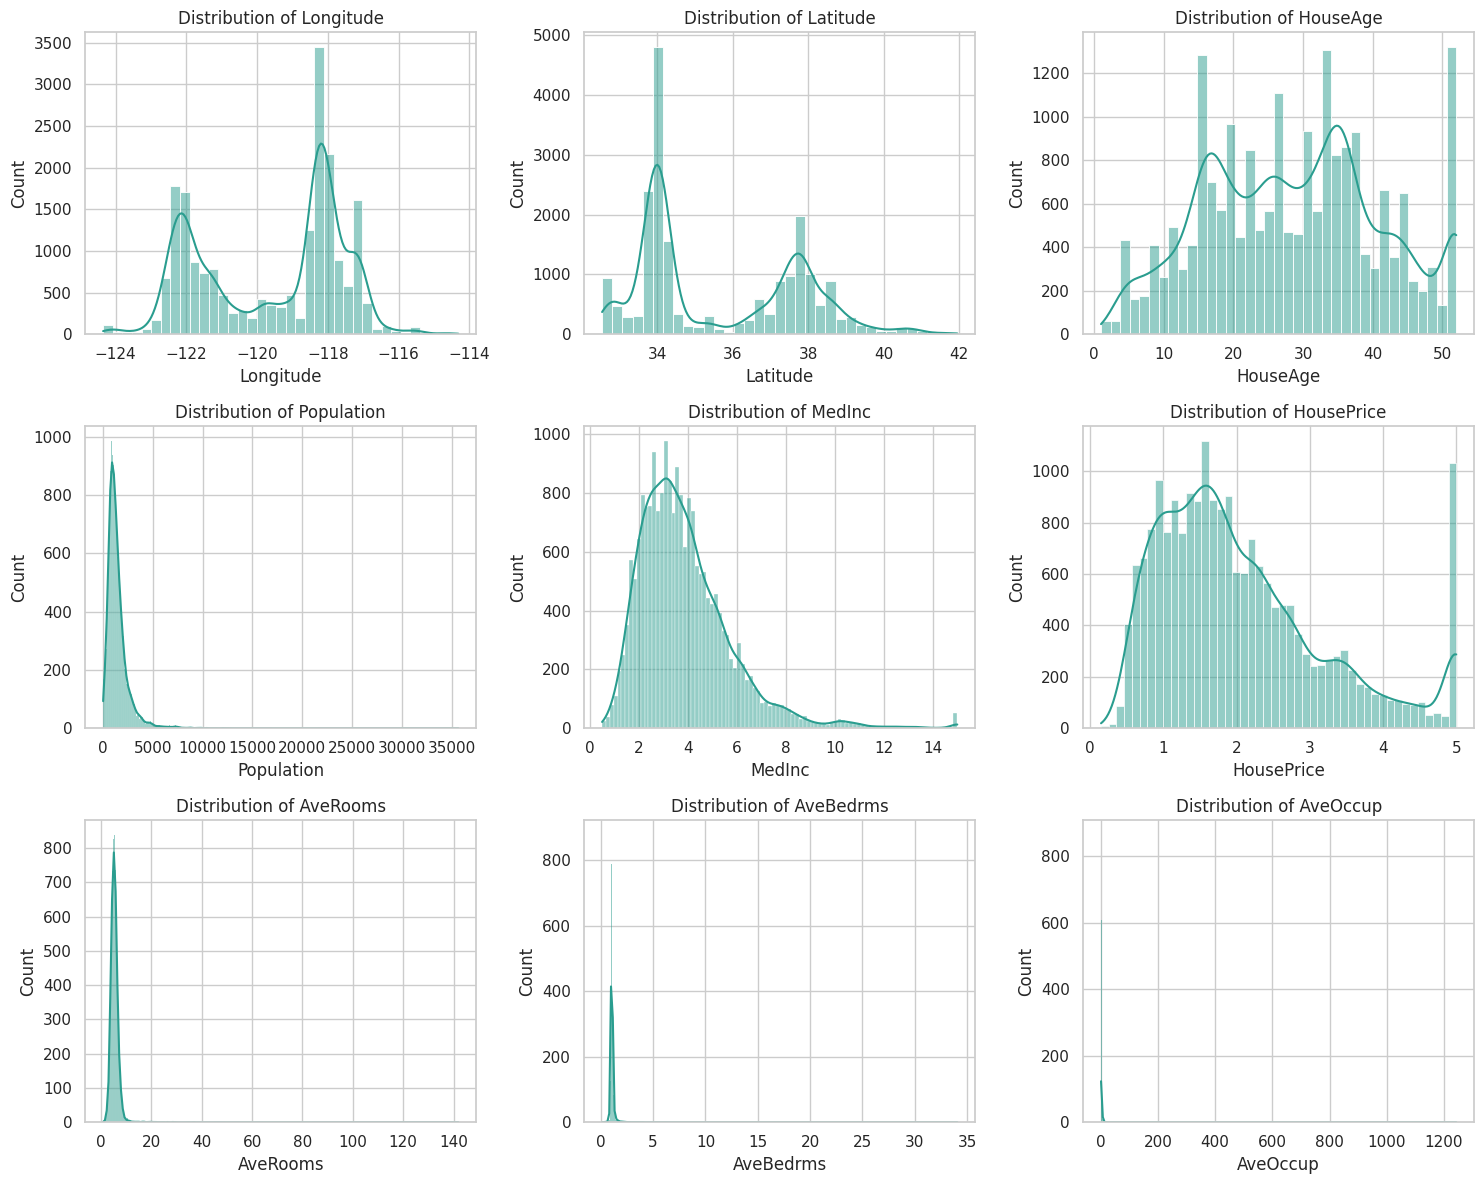

In [5]:
plot_columns = df.select_dtypes(include=np.number).columns[:9]
n_cols = 3
n_rows = int(np.ceil(len(plot_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).flatten()

for i, column in enumerate(plot_columns):
    sns.histplot(df[column], kde=True, ax=axes[i], color='#2a9d8f')
    axes[i].set_title(f'Distribution of {column}')

for j in range(len(plot_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

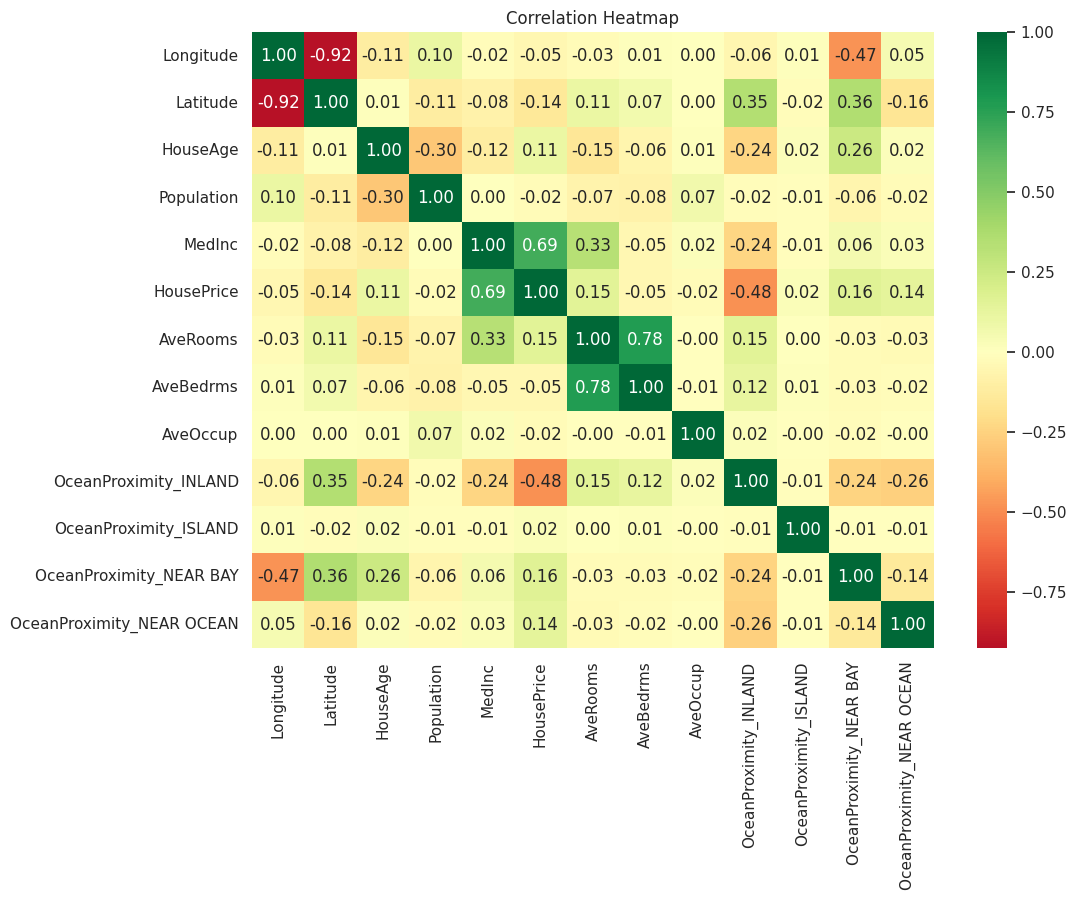

,HousePrice
HousePrice,1.000000
MedInc,0.688075
OceanProximity_NEAR BAY,0.160284
AveRooms,0.151948
OceanProximity_NEAR OCEAN,0.141862
HouseAge,0.105623
OceanProximity_ISLAND,0.023416
AveOccup,-0.023737
Population,-0.024650
AveBedrms,-0.045637


In [6]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f', center=0)
plt.title('Correlation Heatmap')
plt.show()

corr['HousePrice'].sort_values(ascending=False)

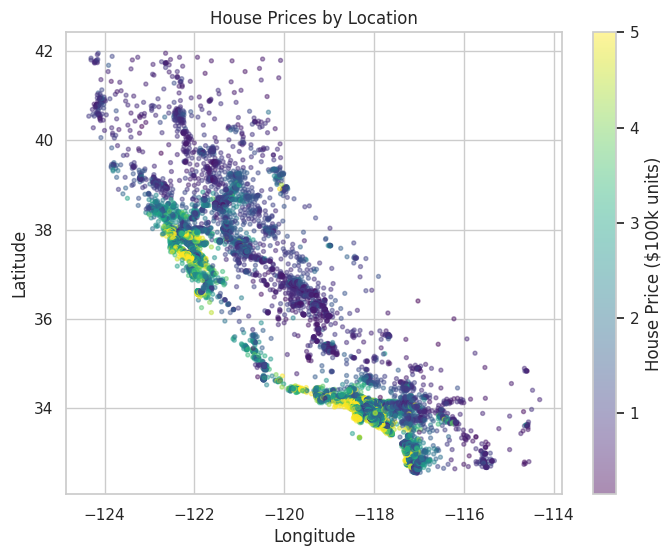

In [7]:
if {'Longitude', 'Latitude', 'HousePrice'}.issubset(df.columns):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        df['Longitude'],
        df['Latitude'],
        c=df['HousePrice'],
        cmap='viridis',
        alpha=0.45,
        s=8
    )
    plt.colorbar(scatter, label='House Price ($100k units)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('House Prices by Location')
    plt.show()

## 5. Feature Engineering

I added extra features that may help models understand room usage and bedroom proportion.

In [8]:
df_engineered = df.copy()

if {'AveRooms', 'AveOccup'}.issubset(df_engineered.columns):
    df_engineered['RoomsPerPerson'] = df_engineered['AveRooms'] / df_engineered['AveOccup']

if {'AveBedrms', 'AveRooms'}.issubset(df_engineered.columns):
    df_engineered['BedroomRatio'] = df_engineered['AveBedrms'] / df_engineered['AveRooms']

df_engineered.replace([np.inf, -np.inf], np.nan, inplace=True)
df_engineered.fillna(df_engineered.median(numeric_only=True), inplace=True)

print('Feature count before engineering:', df.shape[1] - 1)
print('Feature count after engineering:', df_engineered.shape[1] - 1)
df_engineered.head()

Feature count before engineering: 12
Feature count after engineering: 14


,Longitude,Latitude,HouseAge,Population,MedInc,HousePrice,AveRooms,AveBedrms,AveOccup,OceanProximity_INLAND,OceanProximity_ISLAND,OceanProximity_NEAR BAY,OceanProximity_NEAR OCEAN,RoomsPerPerson,BedroomRatio
0,-122.23,37.88,41.0,322.0,8.3252,4.526,6.984127,1.023810,2.555556,0,0,1,0,2.732919,0.146591
1,-122.22,37.86,21.0,2401.0,8.3014,3.585,6.238137,0.971880,2.109842,0,0,1,0,2.956685,0.155797
2,-122.24,37.85,52.0,496.0,7.2574,3.521,8.288136,1.073446,2.802260,0,0,1,0,2.957661,0.129516
3,-122.25,37.85,52.0,558.0,5.6431,3.413,5.817352,1.073059,2.547945,0,0,1,0,2.283154,0.184458
4,-122.25,37.85,52.0,565.0,3.8462,3.422,6.281853,1.081081,2.181467,0,0,1,0,2.879646,0.172096


## 6. Separate Features and Target

In [9]:
X = df_engineered.drop('HousePrice', axis=1)
y = df_engineered['HousePrice']

print('Number of features:', X.shape[1])
print('Target column: HousePrice')
list(X.columns)

Number of features: 14
Target column: HousePrice


['Longitude',
 'Latitude',
 'HouseAge',
 'Population',
 'MedInc',
 'AveRooms',
 'AveBedrms',
 'AveOccup',
 'OceanProximity_INLAND',
 'OceanProximity_ISLAND',
 'OceanProximity_NEAR BAY',
 'OceanProximity_NEAR OCEAN',
 'RoomsPerPerson',
 'BedroomRatio']

## 7. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 16512
Testing rows: 4128


## 8. Feature Scaling

Feature scaling is applied using `StandardScaler`. I use pipelines for the linear models so scaling is learned only from training data and then applied to test data.

In [11]:
scaler_preview = StandardScaler()
X_train_scaled_preview = scaler_preview.fit_transform(X_train)

scaled_preview = pd.DataFrame(X_train_scaled_preview, columns=X.columns)
scaled_preview.describe().T[['mean', 'std']].head()

,mean,std
Longitude,1.753335e-15,1.00003
Latitude,6.400995e-17,1.00003
HouseAge,-9.251859e-18,1.00003
Population,-2.151595e-19,1.00003
MedInc,-6.519333e-17,1.00003


## 9. Train Multiple Models

In [12]:
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

models

{'Linear Regression': Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())]),
 'Ridge Regression': Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())]),
 'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
 'Random Forest': RandomForestRegressor(max_depth=12, n_jobs=-1, random_state=42)}

## 10. Model Evaluation and Comparison

I compare each model using MAE, RMSE, and R2 Score.

- Lower MAE and RMSE are better.
- Higher R2 Score is better.

In [13]:
results = []
trained_models = {}
predictions_by_model = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })
    trained_models[name] = model
    predictions_by_model[name] = predictions

results_df = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2 Score
0,Random Forest,0.339168,0.515623,0.797111
1,Linear Regression,0.482436,0.673856,0.653481
2,Ridge Regression,0.482428,0.673860,0.653477
3,Decision Tree,0.496911,0.712963,0.612094


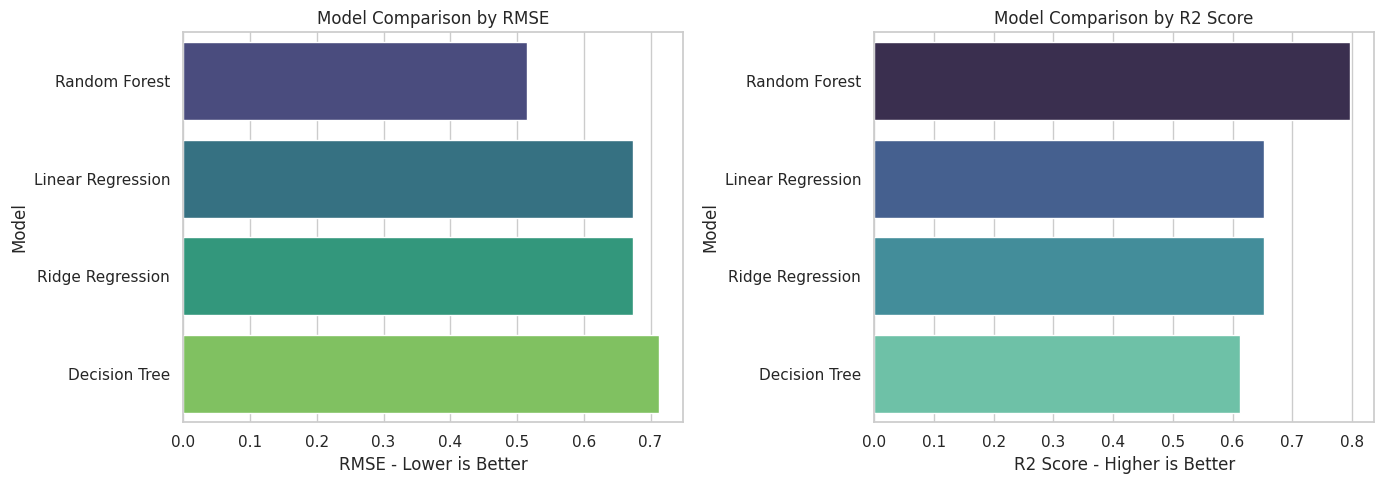

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='RMSE', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Model Comparison by RMSE')
axes[0].set_xlabel('RMSE - Lower is Better')
axes[0].set_ylabel('Model')

sns.barplot(
    data=results_df.sort_values('R2 Score', ascending=False),
    x='R2 Score',
    y='Model',
    palette='mako',
    ax=axes[1]
)
axes[1].set_title('Model Comparison by R2 Score')
axes[1].set_xlabel('R2 Score - Higher is Better')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()

## 11. Select Best Model

I selected the best model using the lowest RMSE because RMSE penalizes large errors more strongly.

In [15]:
best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]
best_predictions = predictions_by_model[best_model_name]
best_metrics = results_df.loc[0]

print('Best model based on RMSE:', best_model_name)
best_metrics

Best model based on RMSE: Random Forest


,0
Model,Random Forest
MAE,0.339168
RMSE,0.515623
R2 Score,0.797111


## 12. Visual Performance Validation

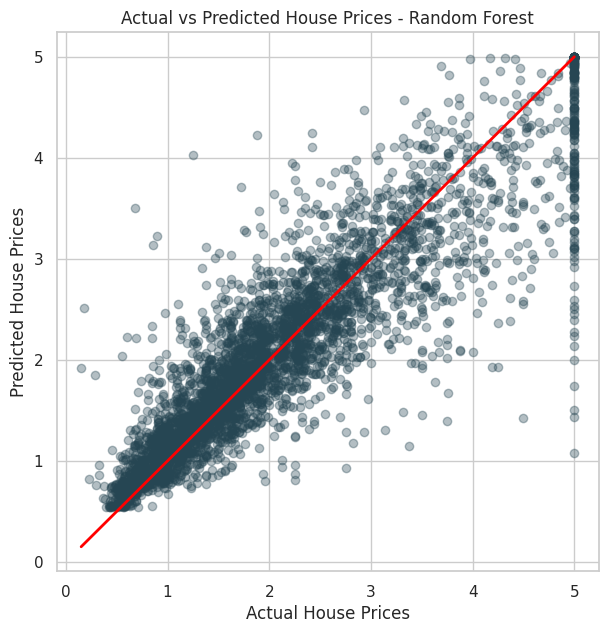

In [16]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_predictions, alpha=0.35, color='#264653')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title(f'Actual vs Predicted House Prices - {best_model_name}')
plt.show()

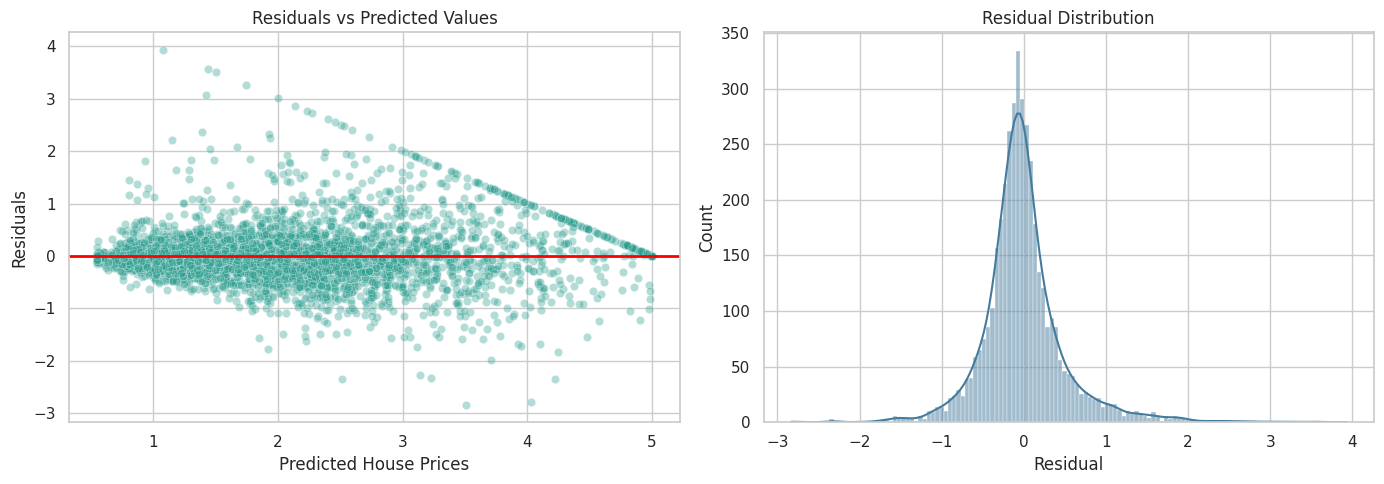

In [17]:
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=best_predictions, y=residuals, alpha=0.35, color='#2a9d8f', ax=axes[0])
axes[0].axhline(0, color='red', linewidth=2)
axes[0].set_xlabel('Predicted House Prices')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted Values')

sns.histplot(residuals, kde=True, color='#457b9d', ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

## 13. Optional Cross-Validation

Cross-validation gives a more stable estimate of model performance across multiple splits.

In [18]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print('Cross-validation R2 scores:', cv_scores)
print('Mean CV R2:', cv_scores.mean())
print('Std CV R2:', cv_scores.std())

Cross-validation R2 scores: [0.42748629 0.62830459 0.72282934 0.48680253 0.73704604]
Mean CV R2: 0.6004937586516257
Std CV R2: 0.12429259269376325


## 14. Save Best Model

In [19]:
model_path = 'task2_best_house_price_model.pkl'
joblib.dump(best_model, model_path)

print(f'Saved best model to {model_path}')

Saved best model to task2_best_house_price_model.pkl


## 15. Final Conclusion

Task 2 shows how real ML workflows improve beyond a single baseline model. Feature engineering, scaling, model comparison, and metric-based selection make the workflow more professional and reliable.